# Decision Tree

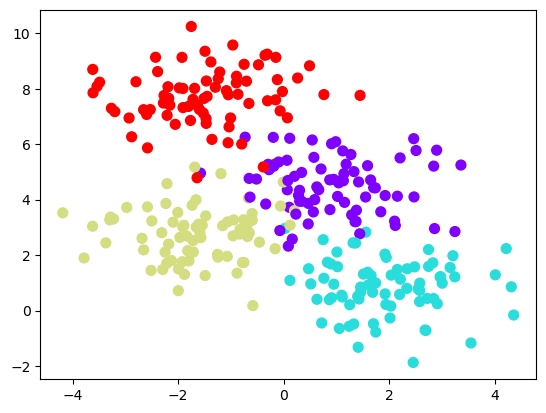

In [7]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow');

In [8]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier().fit(X, y)

In [11]:
def visualize_classifier(model, X, y, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()

    # Plot training points
    ax.scatter(X[:, 0], X[:, 1],
               c=y,
               s=30,
               cmap=cmap,
               zorder=3)

    ax.axis('tight')
    ax.axis('off')

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Fit model
    model.fit(X, y)

    # Create grid
    xx, yy = np.meshgrid(
        np.linspace(*xlim, 200),
        np.linspace(*ylim, 200)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    n_classes = len(np.unique(y))

    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.3,
        levels=np.arange(n_classes + 1) - 0.5,
        cmap=cmap
    )

    ax.set(xlim=xlim, ylim=ylim)


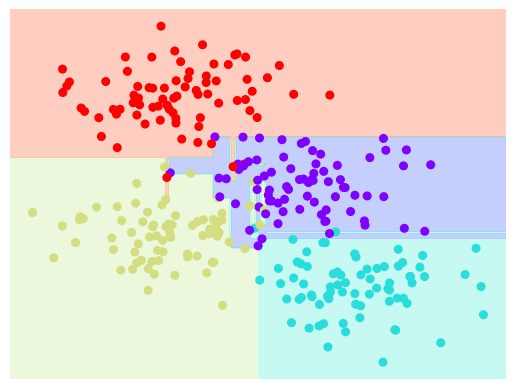

In [12]:
visualize_classifier(DecisionTreeClassifier(), X, y)

(569, 30)


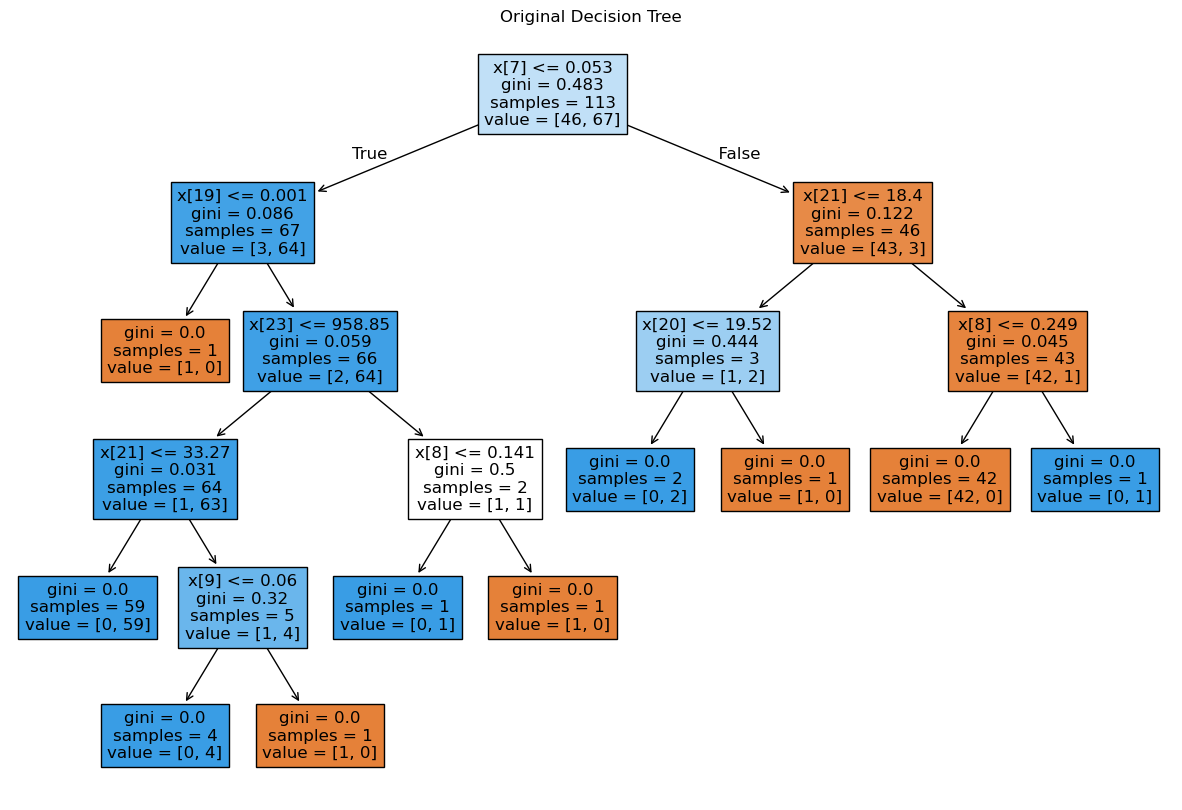

Accuracy 0.8859649122807017
Confusion Matrix:  [[147  19]
 [ 33 257]]


In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
# ------------------------------------------------------------------------------
# Load breast cancer dataset
X, y = load_breast_cancer(return_X_y=True)
print(X.shape)
# ------------------------------------------------------------------------------
# Separating Training and Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=42)
# ------------------------------------------------------------------------------
# Train decision tree model
model = DecisionTreeClassifier(criterion="gini") # entropy
#model = DecisionTreeClassifier(criterion="entropy", random_state=100, max_depth=3, min_samples_leaf=5)
model.fit(X_train, y_train)
# ------------------------------------------------------------------------------
# Plot original tree
plt.figure(figsize=(15, 10))
plot_tree(model, filled=True)
plt.title("Original Decision Tree")
plt.show()
# Model Accuracy before pruning
accuracy = model.score(X_test, y_test)
y_pred = model.predict(X_test)
print("Accuracy", accuracy)
print("Confusion Matrix: ", confusion_matrix(y_test, y_pred))

# Naive Bayes Classifiers

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris
from sklearn import metrics
import matplotlib.pyplot as plt
# ------------------------------------------------------------------------------
iris = load_iris()
X = iris.data # feature matrix (X)
y = iris.target # response vector (y)
# ------------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
print("Gaussian Naive Bayes model accuracy", metrics.accuracy_score(y_test, y_pred)*100,"%")

Gaussian Naive Bayes model accuracy 95.0 %


**Naive Bayes vs Decision Tree Classifiers**


In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
# ------------------------------------------------------------------------------
df = pd.read_csv('Titanic.csv')
print(df.to_string(max_rows=5))
y = df['Survived']
X = df.drop('Survived', axis = 1)
X = X.drop(['Name', 'Ticket', 'Cabin', 'Embarked'], axis = 1)
X = X.replace(['male', 'female'], [2, 3])
X.fillna(method ='ffill', inplace = True) # Handling the missing values
print(X.to_string(max_rows=5))
print("---------------------------------------------------------")
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.3, random_state = 0)
# ------------------------------------------------------------------------------
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
print("Gaussian Naive Bayes model accuracy(in %):", metrics.accuracy_score(y_test, y_pred)*100)
# ------------------------------------------------------------------------------
criteria = ['gini', 'entropy']
for c in criteria:
  dt = DecisionTreeClassifier(criterion = c)
  dt.fit(X_train, y_train)
  y_pred = dt.predict(X_test)
  print(f"DT based on {c} accuracy(in %):", metrics.accuracy_score(y_test, y_pred)*100)
print("---------------------------------------------------------")

     PassengerId  Survived  Pclass                                                 Name     Sex   Age  SibSp  Parch     Ticket     Fare Cabin Embarked
0              1         0       3                              Braund, Mr. Owen Harris    male  22.0      1      0  A/5 21171   7.2500   NaN        S
1              2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.0      1      0   PC 17599  71.2833   C85        C
..           ...       ...     ...                                                  ...     ...   ...    ...    ...        ...      ...   ...      ...
889          890         1       1                                Behr, Mr. Karl Howell    male  26.0      0      0     111369  30.0000  C148        C
890          891         0       3                                  Dooley, Mr. Patrick    male  32.0      0      0     370376   7.7500   NaN        Q
     PassengerId  Pclass  Sex   Age  SibSp  Parch     Fare
0              1       3    2  22.0

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19832\3953799116.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.replace(['male', 'female'], [2, 3])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19832\3953799116.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X.fillna(method ='ffill', inplace = True) # Handling the missing values
